# 🔍 Genesis — Preprocessing Exploration Notebook

This notebook lets you **visually explore everything produced by `src/data/preprocessing.py`** without re-running the pipeline.

**What you'll find here:**
1. Inspect the processed `train / val / test` parquet splits
2. Check the fitted scalers (what median/IQR did RobustScaler learn?)
3. Inspect the PCA model (how much variance does each component capture?)
4. Plot PCA coefficients across time
5. Reconstruct a sample trajectory from PCA coefficients back to sensor space

> ⚠️ Make sure you have run `python src/data/preprocessing.py` at least once before running this notebook.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib

# Make sure we can import from src/
sys.path.insert(0, os.path.abspath('..'))

# Paths
PROCESSED_DIR = '../data/processed'
CHECKPOINT_DIR = '../outputs/checkpoints'

print("✅ Imports ready. Make sure you ran preprocessing.py first!")

✅ Imports ready. Make sure you ran preprocessing.py first!


## 📊 Part 1 — Inspect the Processed Parquet Splits

In [2]:
# Load all three splits
train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'train.parquet'))
val_df   = pd.read_parquet(os.path.join(PROCESSED_DIR, 'val.parquet'))
test_df  = pd.read_parquet(os.path.join(PROCESSED_DIR, 'test.parquet'))

print("=" * 60)
print(f"  TRAIN  →  {train_df.shape[0]:,} rows  x  {train_df.shape[1]} columns")
print(f"  VAL    →  {val_df.shape[0]:,} rows  x  {val_df.shape[1]} columns")
print(f"  TEST   →  {test_df.shape[0]:,} rows  x  {test_df.shape[1]} columns")
print("=" * 60)
print(f"\nColumns:\n{list(train_df.columns)}")

  TRAIN  →  723,921 rows  x  18 columns
  VAL    →  155,126 rows  x  18 columns
  TEST   →  155,127 rows  x  18 columns

Columns:
['COMP_Suction_Pressure', 'COMP_Suction_Drum_Temperature', 'KPI_Fuel_Gas_Lower_Heating_Value', 'Turbine_SHAFT_SPEED', 'UK_14PDCV-504_H-SEL', 'SEAL_GAS_SUP_DE', 'PCA_Coefficient_1', 'PCA_Coefficient_2', 'PCA_Coefficient_3', 'PCA_Coefficient_4', 'PCA_Coefficient_5', 'PCA_Coefficient_6', 'PCA_Coefficient_7', 'PCA_Coefficient_8', 'PCA_Coefficient_9', 'PCA_Coefficient_10', 'PCA_Coefficient_11', 'PCA_Coefficient_12']


In [3]:
# Scroll through first 10 rows of train
train_df.head(10)

,COMP_Suction_Pressure,COMP_Suction_Drum_Temperature,KPI_Fuel_Gas_Lower_Heating_Value,Turbine_SHAFT_SPEED,UK_14PDCV-504_H-SEL,SEAL_GAS_SUP_DE,PCA_Coefficient_1,PCA_Coefficient_2,PCA_Coefficient_3,PCA_Coefficient_4,PCA_Coefficient_5,PCA_Coefficient_6,PCA_Coefficient_7,PCA_Coefficient_8,PCA_Coefficient_9,PCA_Coefficient_10,PCA_Coefficient_11,PCA_Coefficient_12
0,-0.106551,-0.624533,0.23276,0.247094,1.123101,0.182722,41.520435,11.720861,-7.802016,8.681550,-0.449148,5.044072,-4.616578,-1.285839,4.247763,-2.000902,1.886595,1.551767
1,-0.105807,-0.623556,0.23276,0.247103,1.123101,0.182726,41.596800,11.611744,-7.824690,8.745056,-0.558221,5.080803,-4.794634,-1.194420,4.244304,-2.081201,1.795507,1.569552
2,-0.105063,-0.622581,0.23276,0.247111,1.123101,0.182728,41.647707,11.469389,-7.878957,8.819488,-0.658624,5.147320,-4.865655,-1.219431,4.190693,-2.151921,1.783985,1.548128
3,-0.104319,-0.621604,0.23276,0.247120,1.123101,0.182729,41.686613,11.480280,-7.899288,8.841343,-0.677330,5.160778,-4.818965,-1.206205,4.199494,-2.160564,1.808499,1.532346
4,-0.103577,-0.620628,0.23276,0.247128,1.123101,0.182731,41.741514,11.515812,-7.923057,8.843640,-0.683864,5.170804,-4.804899,-1.294216,4.191048,-2.123078,1.802749,1.545328
5,-0.102833,-0.619651,0.23276,0.247137,1.123101,0.182735,41.744942,11.501360,-7.949378,8.834400,-0.662210,5.130298,-4.868796,-1.452600,4.080776,-2.089201,1.851014,1.613891
6,-0.102089,-0.618676,0.23276,0.247147,1.123101,0.182737,41.763897,11.464394,-7.938320,8.836289,-0.575090,5.019294,-4.968058,-1.421744,4.075627,-2.089738,1.858367,1.713557
7,-0.101348,-0.617699,0.23276,0.247155,1.123101,0.182738,41.760380,11.481301,-7.892441,8.817134,-0.509335,4.960119,-5.061798,-1.355142,4.153024,-2.089458,1.761679,1.761903
8,-0.100604,-0.616723,0.23276,0.247164,1.123101,0.182740,41.678322,11.524358,-7.860024,8.793085,-0.481538,4.961206,-4.983117,-1.379358,4.141113,-2.091210,1.729314,1.752682
9,-0.099860,-0.615746,0.23276,0.247172,1.123101,0.182744,41.588921,11.436845,-7.912746,8.786521,-0.471818,5.015233,-4.828456,-1.428092,4.207684,-2.052699,1.746142,1.677763


In [4]:
# Summary statistics for every column
train_df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
COMP_Suction_Pressure,723921.000000,-0.000000,1.000001,-5.710992,-0.186747,0.099048,0.518415,2.934123
COMP_Suction_Drum_Temperature,723921.000000,0.000000,1.000001,-2.263267,-0.400715,-0.064991,0.190234,7.516647
KPI_Fuel_Gas_Lower_Heating_Value,723921.000000,0.000000,1.000001,-4.296640,0.232760,0.232760,0.232760,0.232760
Turbine_SHAFT_SPEED,723921.000000,0.000000,1.000001,-4.141237,0.237040,0.241004,0.246436,0.256774
UK_14PDCV-504_H-SEL,723921.000000,-0.000000,1.000001,-2.036326,-0.739696,-0.638158,1.118328,2.736575
SEAL_GAS_SUP_DE,723921.000000,0.000000,1.000001,-6.204285,0.182145,0.183497,0.183967,0.183967
PCA_Coefficient_1,723921.000000,0.719483,129.823426,-578.849179,29.767885,41.552160,46.304853,53.419901
PCA_Coefficient_2,723921.000000,0.139030,85.356379,-332.999391,12.753839,17.564426,28.880377,120.638572
PCA_Coefficient_3,723921.000000,0.062412,47.672333,-245.637934,-6.032520,-0.678873,2.662043,323.619206
PCA_Coefficient_4,723921.000000,0.279717,42.344916,-282.138787,-8.344120,-1.966165,10.228087,103.147817


## ⚖️ Part 2 — Inspect the Fitted Scalers

In [5]:
x_scaler     = joblib.load(os.path.join(CHECKPOINT_DIR, 'x_scaler.pkl'))
u_scaler     = joblib.load(os.path.join(CHECKPOINT_DIR, 'u_scaler.pkl'))
theta_scaler = joblib.load(os.path.join(CHECKPOINT_DIR, 'theta_base_scaler.pkl'))

x_cols     = ['COMP_Suction_Pressure', 'COMP_Suction_Drum_Temperature', 'KPI_Fuel_Gas_Lower_Heating_Value']
u_cols     = ['Turbine_SHAFT_SPEED', 'UK_14PDCV-504_H-SEL', 'SEAL_GAS_SUP_DE']
theta_cols = [
    'SEAL_GAS_FLTR_DP', 'LUBE_OIL_LVL_XMTR_HI/LO_TNK',
    'KPI_Turbine_Overall_Thermal_Cycle_Efficiency', 'KPI_Gas_COMP_Isentropic_Efficiency',
    'COMP_Discharge_Pressure', 'COMP_Discharge_Temp', 'Exhaust_Temp_Spread_1', 'KPI_Turbine_Heat_Rate'
]

print("📌 X Scaler (StandardScaler) — Condition Variables")
x_info = pd.DataFrame({'mean': x_scaler.mean_, 'std': x_scaler.scale_}, index=x_cols)
print(x_info.to_string(), "\n")

print("📌 U Scaler (StandardScaler) — Control Variables")
u_info = pd.DataFrame({'mean': u_scaler.mean_, 'std': u_scaler.scale_}, index=u_cols)
print(u_info.to_string(), "\n")

print("📌 Theta Scaler (RobustScaler) — Target Variables")
theta_info = pd.DataFrame({'median (center)': theta_scaler.center_, 'IQR (scale)': theta_scaler.scale_}, index=theta_cols)
print(theta_info.to_string())

📌 X Scaler (StandardScaler) — Condition Variables
                                       mean       std
COMP_Suction_Pressure              2.607724  0.474510
COMP_Suction_Drum_Temperature    -19.093228  7.861632
KPI_Fuel_Gas_Lower_Heating_Value  31.385668  7.304700 

📌 U Scaler (StandardScaler) — Control Variables
                            mean         std
Turbine_SHAFT_SPEED  3394.334110  819.642856
UK_14PDCV-504_H-SEL    42.664327   20.951621
SEAL_GAS_SUP_DE         3.460834    0.557442 

📌 Theta Scaler (RobustScaler) — Target Variables
                                              median (center)  IQR (scale)
SEAL_GAS_FLTR_DP                                     0.220711     0.024109
LUBE_OIL_LVL_XMTR_HI/LO_TNK                         57.004510     6.897200
KPI_Turbine_Overall_Thermal_Cycle_Efficiency        34.478570     0.905020
KPI_Gas_COMP_Isentropic_Efficiency                  99.500480     1.555330
COMP_Discharge_Pressure                             30.263150     1.857870
COM

## 🗜️ Part 3 — Inspect the PCA Model

In [6]:
pca = joblib.load(os.path.join(CHECKPOINT_DIR, 'trajectory_pca_model.pkl'))

print(f"Input features (flattened window):  {pca.n_features_in_}")
print(f"Output components:                   {pca.n_components_}")
print(f"Solver used:                         {pca.svd_solver}")
print(f"Total variance captured:             {sum(pca.explained_variance_ratio_) * 100:.2f}%\n")

ev = pd.DataFrame({
    'Component': [f'PCA_{i+1}' for i in range(pca.n_components_)],
    'Explained Variance (%)': pca.explained_variance_ratio_ * 100,
    'Cumulative (%)': np.cumsum(pca.explained_variance_ratio_) * 100
})
ev.set_index('Component')

Input features (flattened window):  1920
Output components:                   12
Solver used:                         full
Total variance captured:             90.34%



,Explained Variance (%),Cumulative (%)
Component,,
PCA_1,48.420676,48.420676
PCA_2,20.620202,69.040878
PCA_3,6.403687,75.444566
PCA_4,5.109883,80.554449
PCA_5,2.276339,82.830788
PCA_6,1.996082,84.826869
PCA_7,1.540816,86.367685
PCA_8,1.082058,87.449743
PCA_9,0.907712,88.357455


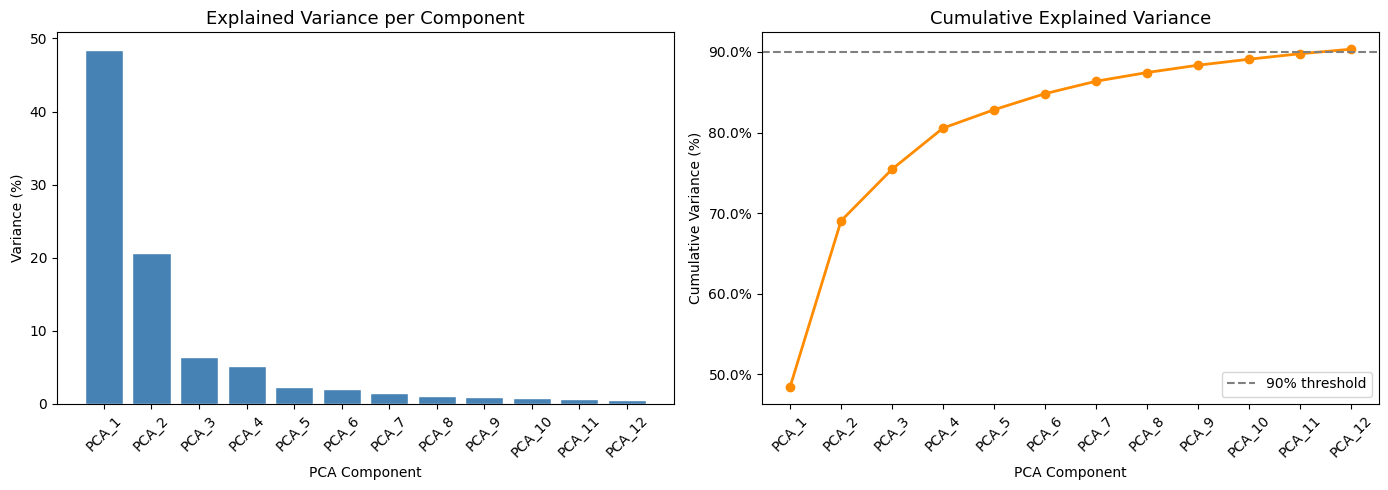

In [7]:
# Plot: Explained Variance per Component
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

components = [f'PCA_{i+1}' for i in range(pca.n_components_)]
ev_pct = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(ev_pct)

axes[0].bar(components, ev_pct, color='steelblue', edgecolor='white')
axes[0].set_title('Explained Variance per Component', fontsize=13)
axes[0].set_ylabel('Variance (%)')
axes[0].set_xlabel('PCA Component')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(components, cumulative, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance', fontsize=13)
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_xlabel('PCA Component')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.show()

## 📈 Part 4 — PCA Coefficients Across Time

Each row in the dataset is one sliding window. The 12 PCA coefficients describe the **shape** of the 4-hour future trajectory for that window. Let's see how they evolve.

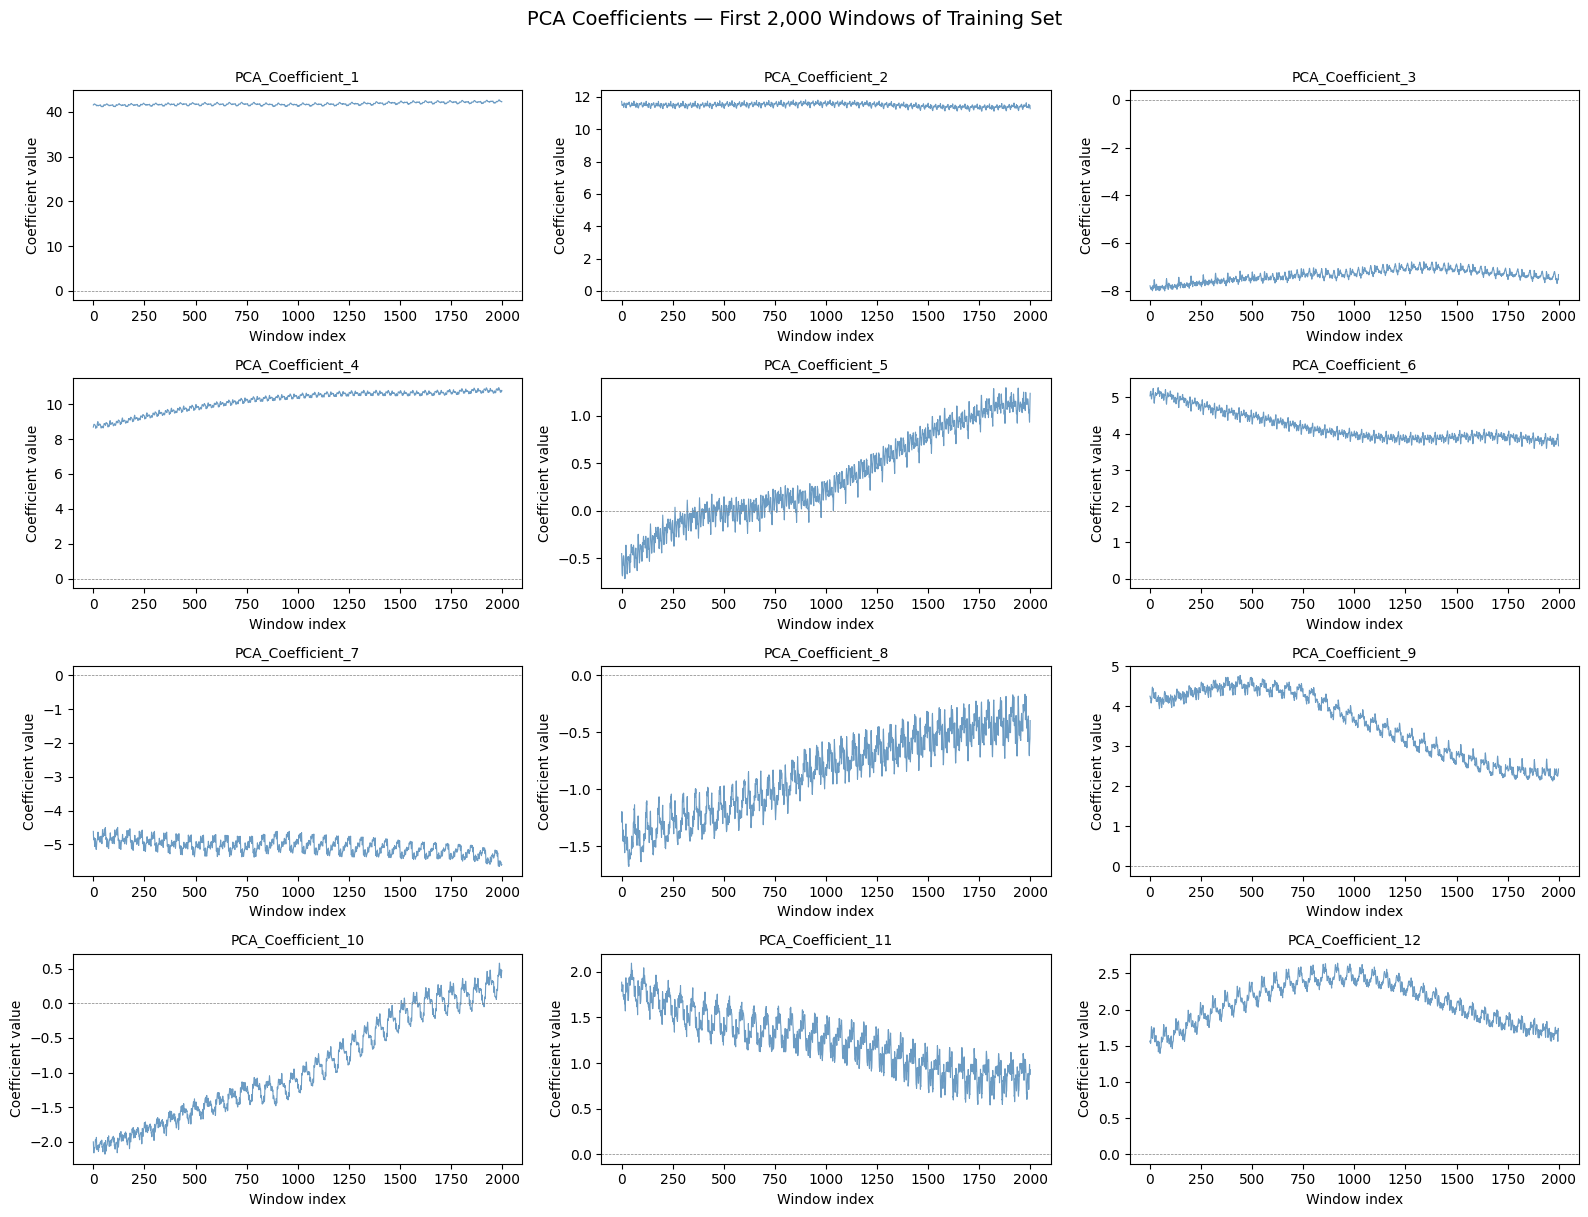

In [8]:
pca_cols = [c for c in train_df.columns if c.startswith('PCA_')]

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(pca_cols):
    axes[i].plot(train_df[col].values[:2000], linewidth=0.8, color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Window index')
    axes[i].set_ylabel('Coefficient value')
    axes[i].axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle('PCA Coefficients — First 2,000 Windows of Training Set', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 🔁 Part 5 — Reconstruct a Sample Trajectory from PCA Coefficients

This proves the PCA compression is lossless enough — take one window's 12 coefficients and reconstruct the approximate 4-hour sensor trajectory.

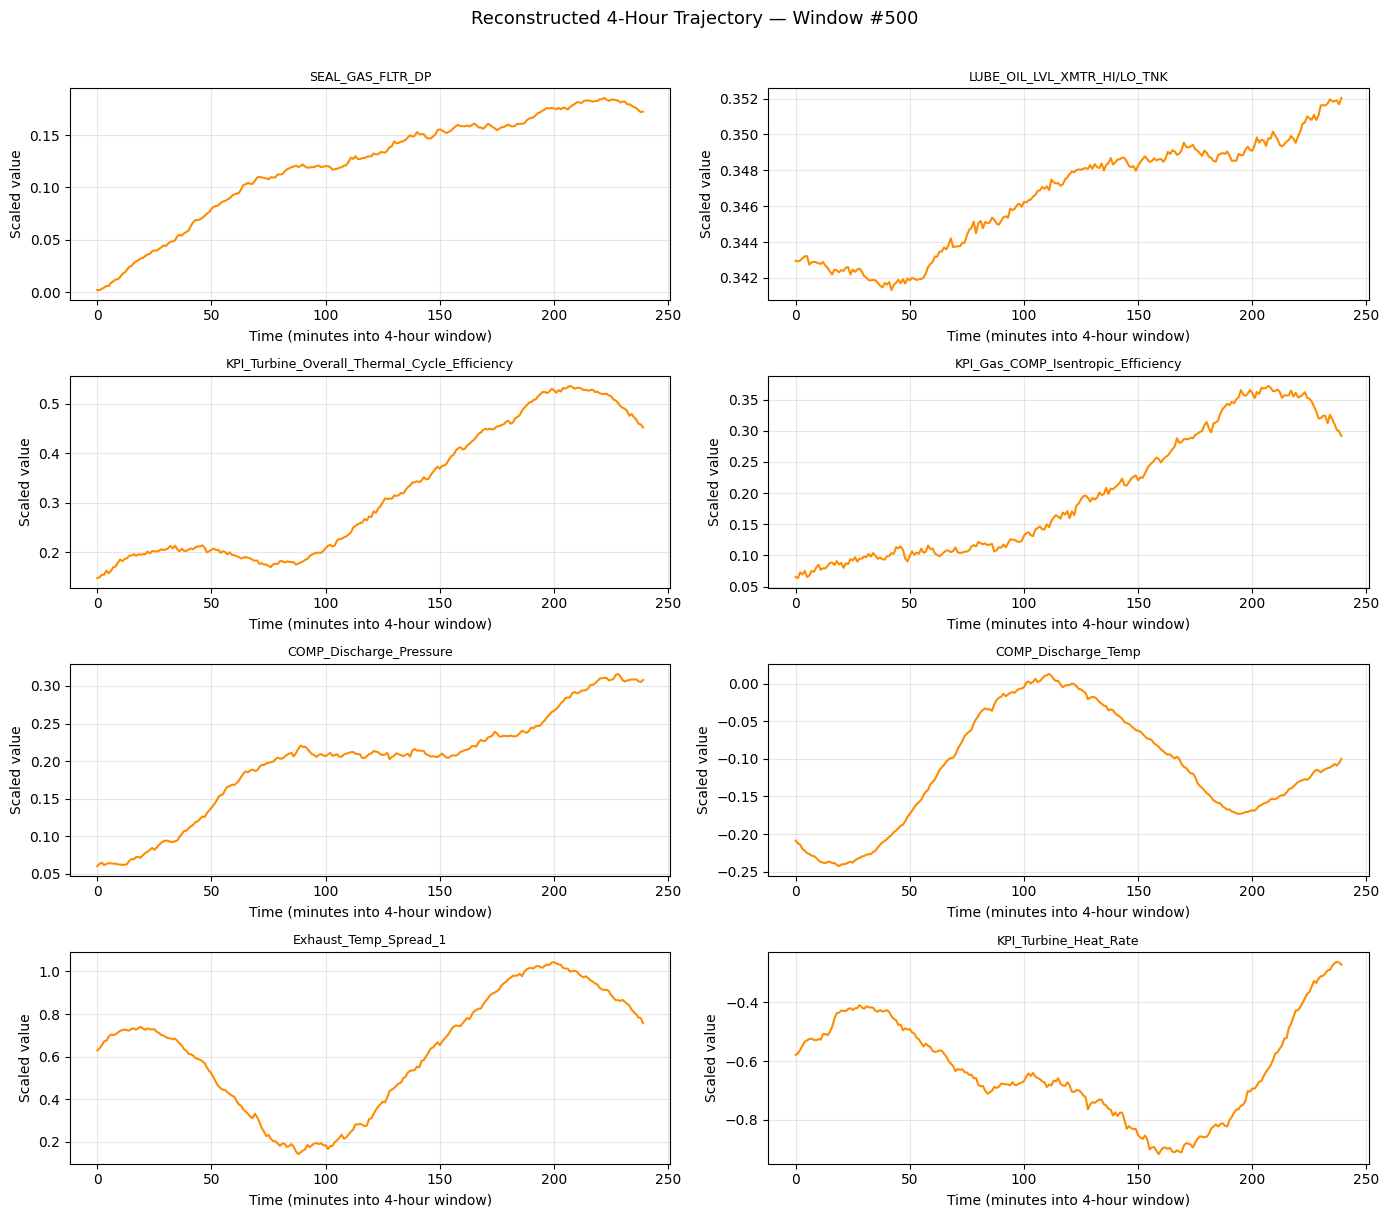


✅ Reconstructed from just 12 PCA coefficients → 240 timesteps x 8 sensors


In [9]:
# Pick a sample window (e.g. window index 500 from training set)
SAMPLE_IDX = 500
DOWNSAMPLE_RATE = 60
N_THETA = len(theta_cols)

# Get the 12 PCA coefficients for this window
coefficients = train_df[pca_cols].values[SAMPLE_IDX]  # shape: (12,)

# Reconstruct the flat compressed trajectory
reconstructed_flat = np.einsum('k,kj->j', coefficients, pca.components_) + pca.mean_
# Shape is (240 * 8,) → reshape to (240 timesteps, 8 sensors)
n_timesteps = reconstructed_flat.shape[0] // N_THETA
reconstructed = reconstructed_flat.reshape(n_timesteps, N_THETA)

# Plot each sensor's reconstructed trajectory
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()
time_axis = np.arange(n_timesteps) * DOWNSAMPLE_RATE / 60  # in minutes

for i, col in enumerate(theta_cols):
    axes[i].plot(time_axis, reconstructed[:, i], linewidth=1.5, color='darkorange')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Time (minutes into 4-hour window)')
    axes[i].set_ylabel('Scaled value')
    axes[i].grid(True, alpha=0.3)

plt.suptitle(f'Reconstructed 4-Hour Trajectory — Window #{SAMPLE_IDX}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"\n✅ Reconstructed from just {len(coefficients)} PCA coefficients → {reconstructed.shape[0]} timesteps x {reconstructed.shape[1]} sensors")